In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cargar_datos_tomografia import cargar_datos_tomografia

In [2]:
datos = cargar_datos_tomografia("datos_tomografia_final_128.npz")

print(datos.keys())

dict_keys(['A', 'b', 'n', 'angulos', 'posiciones_detector', 'ruido_relativo', 'desviacion_ruido', 'norma_ruido_esperada'])


#### a)

In [3]:
A = datos["A"]
b = datos["b"]
n = datos["n"]
angulos = datos["angulos"]
posiciones_detector = datos["posiciones_detector"]

ruido_relativo = datos["ruido_relativo"]
desviacion_ruido = datos["desviacion_ruido"]
norma_ruido_esperada = datos["norma_ruido_esperada"]

K = len(angulos)
q = len(posiciones_detector)

print("n =", n)
print("K =", K)
print("q =", q)
print("A.shape =", A.shape)
print("b.shape =", b.shape)
print("nnz =", A.nnz)
print("ruido relativo =", ruido_relativo)
print("desviación del ruido =", desviacion_ruido)
print("norma esperada del ruido =", norma_ruido_esperada)

n = 128
K = 90
q = 183
A.shape = (16470, 16384)
b.shape = (16470,)
nnz = 1876712
ruido relativo = 0.019999999552965164
desviación del ruido = 0.5919397473335266
norma esperada del ruido = 75.96688842773438


Cargamos los datos del problema y obtuvimos:

- `n = 128`
- `K = 90` ángulos
- `q = 183` posiciones del detector

Como para cada ángulo se toman `q` mediciones, la cantidad total de rayos es:

$$
Kq = 90 \cdot 183 = 16470
$$

La imagen tiene tamaño:

$$
128 \times 128
$$

por lo que, al vectorizarla, tiene:

$$
n^2 = 128^2 = 16384
$$

componentes.

Por lo tanto, la matriz de proyección tiene dimensiones:

$$
A \in \mathbb{R}^{16470 \times 16384}
$$

y el vector de mediciones:

$$
b \in \mathbb{R}^{16470}
$$

Esto coincide con los resultados obtenidos:

- `A.shape = (16470, 16384)`
- `b.shape = (16470,)`

La matriz `A` tiene `1876712` elementos no nulos. Como la mayoría de sus entradas son cero, se almacena como una matriz dispersa.

Además, los datos incluyen una estimación del ruido:

- ruido relativo: aproximadamente `0.02`, es decir, un 2%
- desviación del ruido: aproximadamente `0.592`
- norma esperada del ruido: aproximadamente `75.97`

#### b)

In [4]:
S = b.reshape(K, q)

print("S.shape =", S.shape)

S.shape = (90, 183)


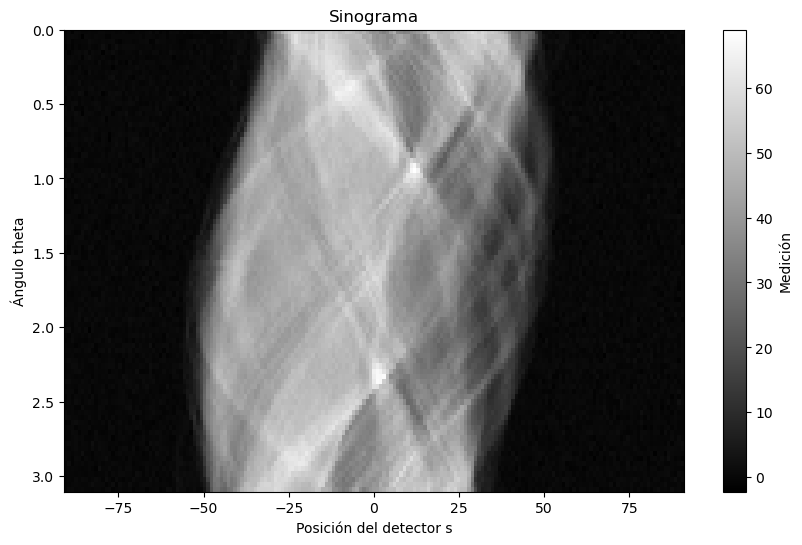

In [5]:
plt.figure(figsize=(10, 6))

plt.imshow(
    S,
    aspect="auto",
    cmap="gray",
    extent=[
        posiciones_detector[0],
        posiciones_detector[-1],
        angulos[-1],
        angulos[0]
    ]
)

plt.colorbar(label="Medición")
plt.xlabel("Posición del detector s")
plt.ylabel("Ángulo theta")
plt.title("Sinograma")

plt.show()

Reorganizamos el vector de mediciones `b` en una matriz:

$$
S \in \mathbb{R}^{K \times q}
$$

donde cada fila corresponde a un ángulo de adquisición y cada columna a una posición del detector.

Como en nuestros datos:

$$
K=90
$$

y:

$$
q=183,
$$

obtenemos:

$$
S \in \mathbb{R}^{90 \times 183}.
$$

El vector `b` ya está ordenado primero por ángulo y luego por posición del detector, por lo que podemos reconstruir el sinograma mediante:

$$
S_{kj}=b_{kq+j}.
$$

En Python, esto se realiza con `b.reshape(K, q)`.

En el sinograma obtenido, el eje horizontal representa la posición del detector `s` y el eje vertical representa el ángulo θ. Las zonas más claras corresponden a mediciones de mayor intensidad y las más oscuras a mediciones menores.

Las estructuras curvas aparecen porque, al cambiar el ángulo de adquisición, una misma región del objeto contribuye a distintas posiciones del detector.

#### c)

In [6]:
from scipy.sparse import lil_matrix, csr_matrix

In [7]:
def matriz_diferencias_sparse(n):
    
    filas = 2 * n * (n - 1)
    columnas = n**2
    
    D = lil_matrix((filas, columnas))
    
    fila = 0
    
    # Diferencias horizontales
    for i in range(n):
        for j in range(n - 1):
            
            k = i * n + j
            
            D[fila, k] = -1
            D[fila, k + 1] = 1
            
            fila += 1
    
    # Diferencias verticales
    for i in range(n - 1):
        for j in range(n):
            
            k = i * n + j
            
            D[fila, k] = -1
            D[fila, k + n] = 1
            
            fila += 1
    
    return D.tocsr()


D = matriz_diferencias_sparse(n)

print("D.shape =", D.shape)
print("Cantidad de no nulos =", D.nnz)

D.shape = (32512, 16384)
Cantidad de no nulos = 65024


In [8]:
#Verificamos que cada fila tiene exactamente dos no nulos
no_nulos_por_fila = np.diff(D.indptr)

print("Mínimo de no nulos por fila:", no_nulos_por_fila.min())
print("Máximo de no nulos por fila:", no_nulos_por_fila.max())

Mínimo de no nulos por fila: 2
Máximo de no nulos por fila: 2


Construimos una matriz de diferencias `D` para medir cuánto cambia la imagen entre píxeles vecinos.

La matriz contiene dos tipos de diferencias:

- horizontales:

$$
X_{i,j+1}-X_{i,j}
$$

- verticales:

$$
X_{i+1,j}-X_{i,j}
$$

Cada fila de `D` compara solamente dos píxeles vecinos, por lo que contiene exactamente un valor `-1` y un valor `1`.

Para una imagen de tamaño:

$$
n\times n
$$

hay:

$$
n(n-1)
$$

pares horizontales y la misma cantidad de pares verticales.

Por lo tanto:

$$
D \in \mathbb{R}^{2n(n-1)\times n^2}
$$

En nuestro caso, con:

$$
n=128,
$$

obtenemos:

$$
D \in \mathbb{R}^{32512\times16384}
$$

Como cada fila tiene exactamente dos elementos no nulos, la cantidad total de valores no nulos esperada es:

$$
2\cdot32512=65024
$$

La matriz se construyó en formato disperso porque la gran mayoría de sus entradas son cero.

Los resultados obtenidos coinciden con lo esperado:

$$
D.shape=(32512,16384)
$$

y:

$$
D.nnz=65024.
$$

Además, verificamos que cada fila tiene exactamente dos elementos no nulos, ya que tanto el mínimo como el máximo de valores no nulos por fila fueron iguales a 2.

#### d)

Queremos minimizar:

$$ J_0(x)=\frac12\|Ax-b\|^2 $$

Como λ=0, todavía no aparece el término de suavidad con \(D\).

El gradiente es:

$$ \nabla J_0(x)=A^T(Ax-b) $$

Entonces usamos la misma actualización que en el ejercicio 8:

$$ x_{t+1}=x_t-\alpha\nabla J_0(x_t) $$

La diferencia es que ahora:

- \(x\) tiene \(16384\) componentes;
- \(A\) es mucho más grande;
- \(A\) es dispersa.

Por eso no queremos construir:

$$ A^TA $$

como matriz densa.

Primero calculamos una tasa de aprendizaje estable

En el ejercicio 8 usábamos:

$$ 0<\alpha<\frac{2}{\mu_{\max}} $$

donde $μ_{max}$ es el mayor autovalor de $ A^TA $.

Como ahora la matriz es grande y dispersa, podemos calcular directamente el mayor autovalor usando eigsh.

In [9]:
from scipy.sparse.linalg import eigsh

def aplicar_H(x):
    return A.T @ (A @ x)

In [10]:
#para eigsh creamos un operador lineal:
from scipy.sparse.linalg import LinearOperator, eigsh

H_op = LinearOperator(
    shape=(n**2, n**2),
    matvec=lambda x: A.T @ (A @ x)
)

mu_max = eigsh(
    H_op,
    k=1,
    which="LM",
    return_eigenvectors=False
)[0]

print("mu_max =", mu_max)
print("2 / mu_max =", 2 / mu_max)

mu_max = 11124.07
2 / mu_max = 0.00017979031


In [11]:
#elegimos:
alpha = 1.0 / mu_max
#que está dentro del intervalo estable.

### ¿Por qué elegimos esta tasa de aprendizaje?

Si `alpha` es demasiado grande, el gradiente descendiente puede volverse inestable y alejarse del mínimo, como vimos en el ejercicio 8.

Por eso elegimos:

$$
\alpha=\frac{1}{\mu_{\max}}
$$

Este valor cumple:

$$
0<\frac{1}{\mu_{\max}}<\frac{2}{\mu_{\max}}
$$

por lo que se encuentra dentro del intervalo de estabilidad y debería permitir que el método converja.

Implementamos gradiente descendiente

In [12]:
def gradiente_descendiente_tomo(A, b, alpha, max_iter=5000, tol=1e-6):
    
    x = np.zeros(A.shape[1])
    
    costos = []
    normas_gradiente = []
    
    for t in range(max_iter):
        
        residuo = A @ x - b
        grad = A.T @ residuo
        
        costo = 0.5 * np.linalg.norm(residuo)**2
        
        costos.append(costo)
        normas_gradiente.append(np.linalg.norm(grad))
        
        x_nuevo = x - alpha * grad
        
        if np.linalg.norm(x_nuevo - x) < tol * max(1, np.linalg.norm(x)):
            x = x_nuevo
            break
        
        x = x_nuevo
    
    return x, costos, normas_gradiente, t + 1

No queremos obligatoriamente hacer 5000 iteraciones si ya casi no cambia la solución.

Comparamos:

$$ \|x_{t+1}-x_t\| $$

con el tamaño de $x_t$.

Si el cambio es extremadamente chico, frenamos.

Reconstrucción sin regularización:

In [13]:
x_sin_reg, costos_0, gradientes_0, iter_0 = gradiente_descendiente_tomo(
    A,
    b,
    alpha,
    max_iter=5000,
    tol=1e-6
)

print("Iteraciones:", iter_0)
print("Costo final:", costos_0[-1])

Iteraciones: 5000
Costo final: 850.0107723309828


Volvemos a convertir el vector en imagen.

In [14]:
X_sin_reg = x_sin_reg.reshape(n, n)

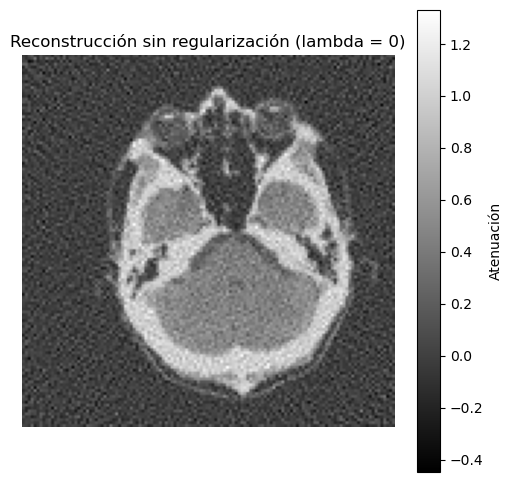

In [15]:
plt.figure(figsize=(6, 6))

plt.imshow(X_sin_reg, cmap="gray")
plt.colorbar(label="Atenuación")
plt.title("Reconstrucción sin regularización (lambda = 0)")
plt.axis("off")

plt.show()

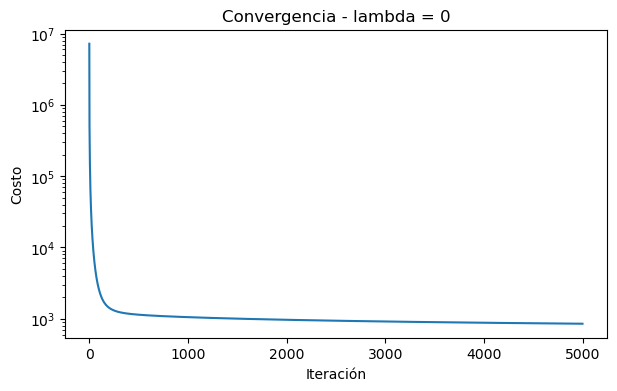

In [16]:
plt.figure(figsize=(7, 4))

plt.plot(costos_0)
plt.yscale("log")

plt.xlabel("Iteración")
plt.ylabel("Costo")
plt.title("Convergencia - lambda = 0")

plt.show()

Para obtener una primera reconstrucción utilizamos gradiente descendiente sin regularización, es decir, con:

$$
\lambda=0
$$

En este caso minimizamos solamente:

$$
J_0(x)=\frac{1}{2}\|Ax-b\|^2
$$

El gradiente es:

$$
\nabla J_0(x)=A^T(Ax-b)
$$

y actualizamos la reconstrucción mediante:

$$
x_{t+1}=x_t-\alpha\nabla J_0(x_t)
$$

Comenzamos desde una imagen nula:

$$
x_0=0
$$

Para elegir una tasa de aprendizaje estable calculamos aproximadamente el mayor autovalor de $A^TA$ y utilizamos un valor de `alpha` dentro del intervalo:

$$
0<\alpha<\frac{2}{\mu_{\max}}
$$

Como la matriz `A` es grande y dispersa, evitamos construir directamente $A^TA$ como una matriz densa.

Durante las iteraciones registramos el costo:

$$
J_0(x)=\frac12\|Ax-b\|^2
$$

Finalmente, el vector reconstruido de 16384 componentes se reorganiza como una imagen de:

$$
128\times128
$$

La reconstrucción obtenida permite recuperar una estructura anatómica reconocible, aunque presenta bastante ruido y variaciones entre píxeles.

Esto es esperable porque, al usar:

$$
\lambda=0
$$

el algoritmo solamente intenta ajustarse a las mediciones y no impone ninguna condición de suavidad sobre la imagen.

La curva del costo muestra que el método disminuye rápidamente el error durante las primeras iteraciones y luego continúa descendiendo más lentamente.

Después de 5000 iteraciones se obtuvo un costo final aproximado de:

$$
850.01
$$

Esta reconstrucción sin regularización servirá como referencia para comparar luego el efecto de agregar el término de regularización.

#### e)

La función que ahora queremos minimizar es:

$$ J_\lambda(x)=\frac12\left(\|Ax-b\|^2+\lambda\|Dx\|^2\right) $$

La idea simple es:

- $||Ax-b\|^2$ obliga a que la reconstrucción explique bien las mediciones.
- $||Dx\|^2$ penaliza cambios bruscos entre píxeles vecinos.
- $\lambda$ decide cuánto peso le damos a esa suavidad.

Si $\lambda$ es muy chico, la imagen puede quedar ruidosa. Si es muy grande, puede quedar demasiado suavizada.

In [17]:
def gradiente_regularizado(A, D, b, lam, alpha, max_iter=5000, tol=1e-6):
    
    x = np.zeros(A.shape[1])
    
    costos = []
    
    for t in range(max_iter):
        
        residuo = A @ x - b
        Dx = D @ x
        
        grad = A.T @ residuo + lam * (D.T @ Dx)
        
        costo = 0.5 * (
            np.linalg.norm(residuo)**2
            + lam * np.linalg.norm(Dx)**2
        )
        
        costos.append(costo)
        
        x_nuevo = x - alpha * grad
        
        if np.linalg.norm(x_nuevo - x) < tol * max(1, np.linalg.norm(x)):
            x = x_nuevo
            break
        
        x = x_nuevo
    
    return x, costos, t + 1

Al agregar regularización cambia la Hessiana:

$$ H_\lambda=A^TA+\lambda D^TD $$

por lo tanto también cambia el límite estable de $\alpha$.

Podemos estimar el mayor autovalor con un LinearOperator:

In [18]:
from scipy.sparse.linalg import LinearOperator, eigsh

def calcular_mu_max_regularizado(A, D, lam):
    
    ncols = A.shape[1]
    
    H_op = LinearOperator(
        shape=(ncols, ncols),
        matvec=lambda x: A.T @ (A @ x) + lam * (D.T @ (D @ x))
    )
    
    mu_max = eigsh(
        H_op,
        k=1,
        which="LM",
        return_eigenvectors=False
    )[0]
    
    return mu_max

Ahora probamos los valores de $\lambda$:

In [19]:
lambdas = [0.1, 1, 10, 30, 100]

reconstrucciones = {}
costos_reg = {}
iteraciones_reg = {}
alphas_reg = {}

In [20]:
for lam in lambdas:
    
    mu_max_lam = calcular_mu_max_regularizado(A, D, lam)
    
    alpha_lam = 1.0 / mu_max_lam
    
    x_reg, costos, iters = gradiente_regularizado(
        A,
        D,
        b,
        lam,
        alpha_lam,
        max_iter=5000,
        tol=1e-6
    )
    
    reconstrucciones[lam] = x_reg
    costos_reg[lam] = costos
    iteraciones_reg[lam] = iters
    alphas_reg[lam] = alpha_lam
    
    print(
        f"lambda={lam}, alpha={alpha_lam:.6e}, "
        f"iteraciones={iters}, costo final={costos[-1]:.3f}"
    )

lambda=0.1, alpha=8.989514e-05, iteraciones=5000, costo final=922.286
lambda=1, alpha=8.989513e-05, iteraciones=5000, costo final=1321.195
lambda=10, alpha=8.989507e-05, iteraciones=1476, costo final=3244.792
lambda=30, alpha=8.989493e-05, iteraciones=656, costo final=5988.245
lambda=100, alpha=8.989440e-05, iteraciones=355, costo final=11843.092


Para visualizar las reconstrucciones usamos una escala común para compararlas bien:

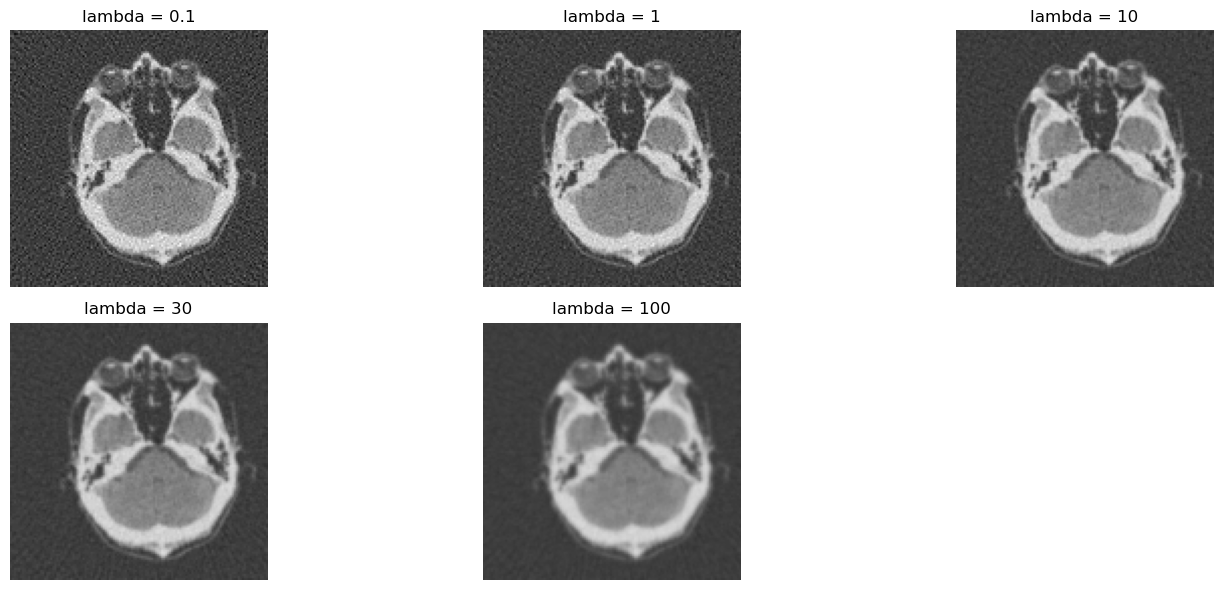

In [21]:
vmin = min(np.min(x) for x in reconstrucciones.values())
vmax = max(np.max(x) for x in reconstrucciones.values())

plt.figure(figsize=(15, 6))

for k, lam in enumerate(lambdas):
    
    X_reg = reconstrucciones[lam].reshape(n, n)
    
    plt.subplot(2, 3, k+1)
    plt.imshow(X_reg, cmap="gray", vmin=vmin, vmax=vmax)
    plt.title(f"lambda = {lam}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Ahora agregamos regularización para penalizar cambios bruscos entre píxeles vecinos.

La función objetivo pasa a ser:

$$
J_\lambda(x)
=
\frac12
\left(
\|Ax-b\|^2
+
\lambda\|Dx\|^2
\right)
$$

El primer término:

$$
\|Ax-b\|^2
$$

mide qué tan bien la reconstrucción reproduce las mediciones.

El segundo término:

$$
\|Dx\|^2
$$

mide cuánto cambia la imagen entre píxeles vecinos.

El parámetro:

$$
\lambda
$$

controla el compromiso entre ajustar bien las mediciones y obtener una imagen más suave.

Probamos los valores:

$$
\lambda \in \{0.1,1,10,30,100\}
$$

En las reconstrucciones se observa que, a medida que aumenta `lambda`, la imagen se vuelve progresivamente más suave y disminuye el ruido.

Con valores pequeños, como `lambda = 0.1` y `lambda = 1`, todavía se conserva bastante ruido.

Con valores intermedios, como `lambda = 10` y `lambda = 30`, se reduce gran parte del ruido manteniendo todavía bastante estructura de la imagen.

Con `lambda = 100`, la reconstrucción se vuelve mucho más suave y empiezan a perderse algunos detalles.

También observamos que el costo final aumenta al crecer `lambda`. Esto no significa necesariamente que la reconstrucción sea peor, porque ahora el costo incluye también el término de regularización:

$$
\lambda\|Dx\|^2
$$

Por eso, para comparar las reconstrucciones no alcanza con mirar solamente el valor final de $J_\lambda(x)$.

Las iteraciones obtenidas fueron:

- `lambda = 0.1`: 5000 iteraciones
- `lambda = 1`: 5000 iteraciones
- `lambda = 10`: 1476 iteraciones
- `lambda = 30`: 656 iteraciones
- `lambda = 100`: 355 iteraciones

La elección final de `lambda` se realizará comparando no solo la apariencia visual, sino también el residuo y la variación de la imagen.

#### f)

In [22]:
resultados_f = []

for lam in lambdas:
    
    x_reg = reconstrucciones[lam]
    
    residuo = A @ x_reg - b
    norma_residuo = np.linalg.norm(residuo)
    
    variacion = np.linalg.norm(D @ x_reg)
    
    minimo = np.min(x_reg)
    maximo = np.max(x_reg)
    
    resultados_f.append([
        lam,
        alphas_reg[lam],
        iteraciones_reg[lam],
        norma_residuo,
        variacion,
        minimo,
        maximo
    ])

In [23]:
import pandas as pd

tabla_f = pd.DataFrame(
    resultados_f,
    columns=[
        "lambda",
        "alpha",
        "iteraciones",
        "norma_residuo",
        "norma_Dx",
        "min",
        "max"
    ]
)

tabla_f

,lambda,alpha,iteraciones,norma_residuo,norma_Dx,min,max
0,0.1,0.00009,5000,41.630869,33.378290,-0.418492,1.311571
1,1.0,0.00009,5000,44.574341,25.603067,-0.280920,1.210116
2,10.0,0.00009,1476,55.387143,18.498241,-0.150283,1.108653
3,30.0,0.00009,656,71.536254,15.120685,-0.104142,1.076756
4,100.0,0.00009,355,102.636232,11.468212,-0.062664,1.050557


In [24]:
print("Norma esperada del ruido =", norma_ruido_esperada)

Norma esperada del ruido = 75.96688842773438


Los resultados muestran que, cuando aumenta `lambda`, la imagen se vuelve más suave.

Al mismo tiempo, la norma del residuo:

$$
\|A\hat{x}_\lambda-b\|
$$

aumenta. Esto significa que la reconstrucción se aleja un poco más de las mediciones originales.

Por otro lado, la norma:

$$
\|D\hat{x}_\lambda\|
$$

disminuye, lo que muestra que hay menos cambios bruscos entre píxeles vecinos.

Los valores obtenidos fueron:

- `lambda = 0.1`: residuo ≈ 41.63, variación ≈ 33.38
- `lambda = 1`: residuo ≈ 44.57, variación ≈ 25.60
- `lambda = 10`: residuo ≈ 55.39, variación ≈ 18.50
- `lambda = 30`: residuo ≈ 71.54, variación ≈ 15.12
- `lambda = 100`: residuo ≈ 102.64, variación ≈ 11.47

La norma esperada del ruido es aproximadamente:

$$
75.97
$$

Por eso, `lambda = 30` parece una buena opción, porque su residuo queda muy cerca del nivel de ruido esperado y la imagen ya se ve bastante más limpia.

En cambio, con `lambda = 100` la imagen se suaviza más, pero el residuo queda bastante por encima del ruido esperado, por lo que probablemente se estén perdiendo demasiados detalles.

#### e)


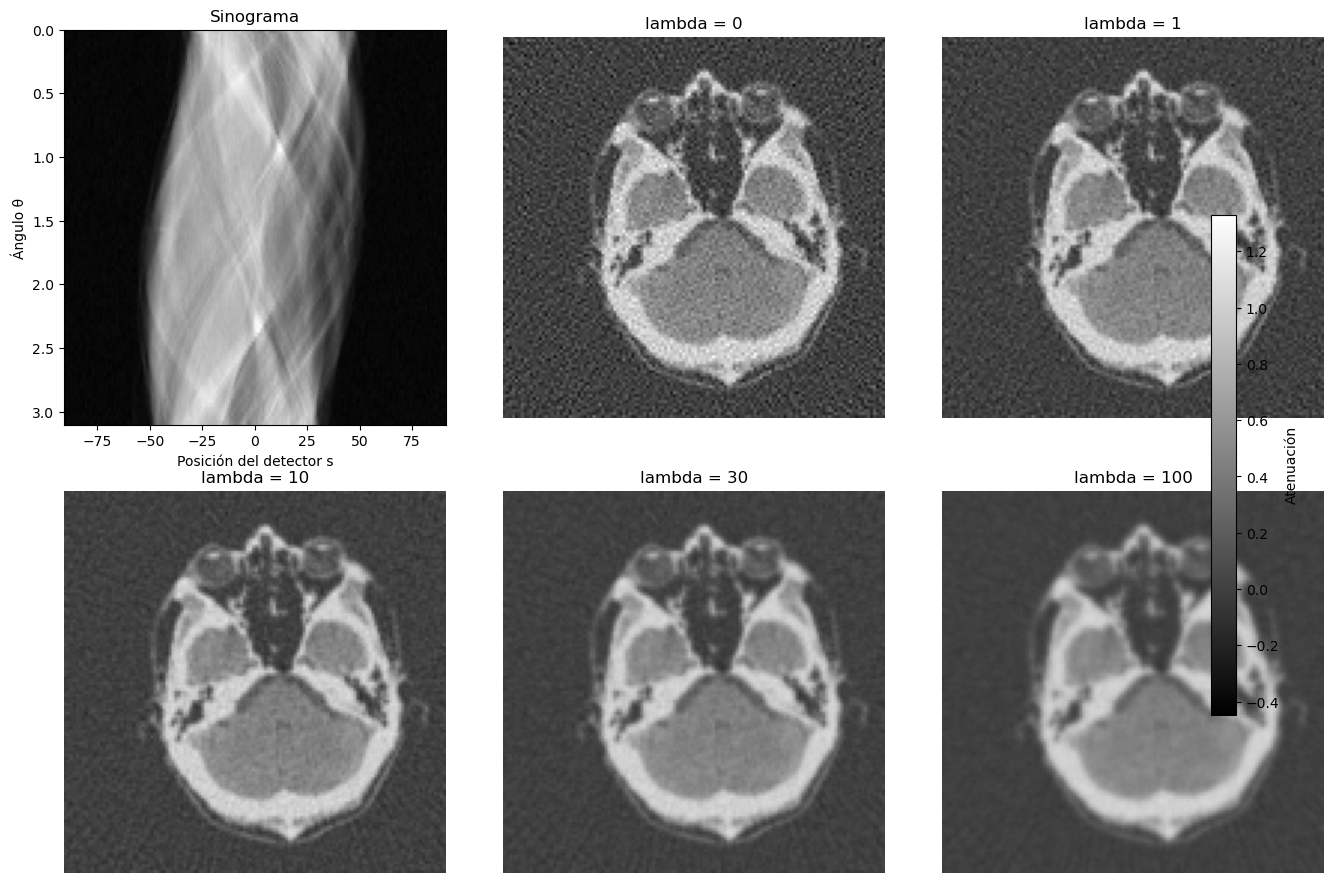

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Sinograma
axes[0, 0].imshow(
    S,
    aspect="auto",
    cmap="gray",
    extent=[
        posiciones_detector[0],
        posiciones_detector[-1],
        angulos[-1],
        angulos[0]
    ]
)

axes[0, 0].set_title("Sinograma")
axes[0, 0].set_xlabel("Posición del detector s")
axes[0, 0].set_ylabel("Ángulo θ")

# Reconstrucciones a comparar
imagenes = {
    "lambda = 0": x_sin_reg,
    "lambda = 1": reconstrucciones[1],
    "lambda = 10": reconstrucciones[10],
    "lambda = 30": reconstrucciones[30],
    "lambda = 100": reconstrucciones[100]
}

# Escala común para todas las reconstrucciones
vmin = min(np.min(x) for x in imagenes.values())
vmax = max(np.max(x) for x in imagenes.values())

titulos = list(imagenes.keys())
vectores = list(imagenes.values())

for ax, titulo, x in zip(axes.flat[1:], titulos, vectores):
    im = ax.imshow(
        x.reshape(n, n),
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(titulo)
    ax.axis("off")

# Barra de color común, colocada afuera
fig.colorbar(
    im,
    ax=axes[:, 1:].ravel().tolist(),
    shrink=0.65,
    pad=0.04,
    label="Atenuación"
)

plt.subplots_adjust(
    left=0.06,
    right=0.90,
    top=0.93,
    bottom=0.08,
    wspace=0.15,
    hspace=0.15
)

plt.show()

# Opción 1

Elegimos `lambda = 30` como la reconstrucción más adecuada.

La reconstrucción sin regularización (`lambda = 0`) conserva las estructuras principales, pero presenta bastante ruido.

Con valores pequeños de `lambda`, como `1` y `10`, el ruido disminuye de a poco y la imagen se vuelve más limpia.

Con `lambda = 30`, la imagen se ve bastante más suave pero todavía conserva bien las estructuras principales.

Además, para este valor obtuvimos una norma del residuo de aproximadamente:

$$
71.54
$$

mientras que la norma esperada del ruido es:

$$
75.97
$$

Como ambos valores son cercanos, la reconstrucción no está tratando de ajustarse demasiado al ruido de las mediciones.

En cambio, con `lambda = 100` la imagen se vuelve demasiado suave y algunos detalles empiezan a perderse.

Por estas razones, consideramos que `lambda = 30` es una buena elección para la reconstrucción final.

# Opcion 2
Elegimos `lambda = 10` como reconstrucción final.

La reconstrucción sin regularización (`lambda = 0`) se ve más nítida, pero también presenta bastante ruido.

Al aumentar `lambda`, la imagen se vuelve más suave. Con `lambda = 30` y `lambda = 100` se elimina más ruido, pero también se pierden algunos detalles.

Con `lambda = 10` se reduce una parte importante del ruido y, al mismo tiempo, se conservan mejor las estructuras principales de la imagen.

Además, su norma del residuo es aproximadamente:

$$
55.39
$$

que todavía se encuentra por debajo de la norma esperada del ruido:

$$
75.97
$$

Por eso consideramos que `lambda = 10` da una reconstrucción más equilibrada entre limpieza de ruido y conservación de detalles.